# Cleaned-Data Benchmark: Same-Condition Conflict Removal

This notebook is the first cleaned-data benchmark for the XGBoost pipeline.
It compares the baseline dataset against a cleaned version where exact duplicate duplex groups with the same conditions and large label disagreement are removed.

## Why This Benchmark Matters

- The duplicate-audit notebook identified exact duplicate duplexes under identical conditions with very large `Inhibition` disagreements.
- Those rows are much stronger cleanup candidates than broad patent or concentration removals.
- This notebook tests whether removing those rows improves held-out by-gene performance enough to justify a cleaned dataset for classical ML and CNN training.

## Benchmark Plan

1. Load and rebuild the full cleaned dataset with the same shared preprocessing.
Why: the benchmark must stay aligned with the existing by-gene investigation setup.

2. Load the exported same-condition conflict shortlist.
Why: this defines the conservative row-removal set.

3. Build two datasets.
- Full dataset
- Dataset with thresholded same-condition conflict rows removed
Why: this isolates the effect of the duplicate-conflict cleanup.

4. Evaluate both with the same grouped CV and the same frozen XGBoost parameters.
Why: the comparison should differ only in the data, not in the model or split strategy.

5. Compare overall metrics and hotspot slices after cleanup.
Why: we want to know whether cleanup helps globally, locally, or both.

In [5]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

project_root = Path.cwd().resolve()
while not (project_root / "utils").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if not (project_root / "utils").exists():
    raise RuntimeError("Could not locate project root containing the utils package")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from utils.merge_historic_data import load_merged_dataset
from utils.pipeline import SiRNADataPipeline
from utils.splitter import GroupKFoldLeakPerGroup
from classical_ml.xgboost.export_same_condition_conflicts import SameConditionConflictExporter

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
FROZEN_PARAMS = {
    "n_estimators": 800,
    "max_depth": 4,
    "learning_rate": 0.15881823130907038,
    "subsample": 0.8812898741586134,
    "colsample_bytree": 0.7824379872752019,
    "min_child_weight": 4,
    "reg_lambda": 0.8342807691178866,
    "reg_alpha": 1.4296995092035882,
    "gamma": 0.07531958697602548,
}

processed_dir = Path(
    os.environ.get(
        "CMSIRNA_PROCESSED_DIR",
        project_root / "classical_ml" / "xgboost" / "outputs",
    )
)
duplicate_range_threshold = float(os.environ.get("CMSIRNA_DUPLICATE_RANGE_THRESHOLD", "40"))

print("Processed output dir:", processed_dir)
print("Duplicate range threshold:", duplicate_range_threshold)

Processed output dir: /Users/yesminemaalej/siRNA-Pharmaceutical-Modeling-with-Foundation-Models/data/processed
Duplicate range threshold: 40.0


## Step 1: Load And Rebuild The Base Dataset

Why: the full and cleaned benchmarks must come from the same preprocessed dataframe.

In [7]:
cmsirna_path = os.environ.get("CMSIRNA_RAW_DATA_PATH")
historic_path = os.environ.get("CMSIRNA_RAW_HISTORIC_DATA_PATH")

assert cmsirna_path, "CMSIRNA_RAW_DATA_PATH is not set"
assert historic_path, "CMSIRNA_RAW_HISTORIC_DATA_PATH is not set"

raw_df = load_merged_dataset(cmsirna_path, historic_path)
pipeline = SiRNADataPipeline(target_len=25, fetch_missing_mrna=True)
enriched_df = pipeline.enrich_dataset_with_encodings(
    raw_df,
    strict_cleaning=True,
    add_mrna=True,
)
X_full, groups_full, y_full = pipeline.prepare_for_classical_ml(
    enriched_df,
    target_column="Inhibition",
    use_normalized_conditions=False,
)

mask = ~np.isnan(y_full)
X_full = X_full[mask]
groups_full = groups_full[mask]
y_full = y_full[mask]
analysis_df = enriched_df.loc[mask].reset_index(drop=True).copy()

analysis_df["patent_group"] = analysis_df.get(
    "patent_ID", pd.Series(index=analysis_df.index, dtype=object)
).fillna("HISTORIC_OR_UNKNOWN")

analysis_df.shape, X_full.shape

loaded 3515 historic rows
merged 43153 CMsiRNA and 3515 historic rows into 46668
Running qc and data cleaning
dropped 4233 rows for in-vivo readings
dropped 565 rows for mM readings
dropped 115 rows for unknown or unwanted cell lines
dropped 47 rows for out-of-range inhibition
dropped 1749 rows for missing or unknown concentration
dropped 796 rows for concentration > 200 nM
filled 7522 rows for missing time of administration
dropped 2198 rows with a missing or >25 nt strand
dropped 6 columns: ['Modification_locations_Sense_strand', 'Modification_locations_Antisense_strand', 'Modifications_sense_strand', 'Modifications_AntiSense_strand_3_5', 'position_Antisense_strand', 'position_Sense_strand']
Mapping mRNA structural profiles
Error reading reference dataset: [Errno 2] No such file or directory: '/home/larsena8/software/fennec/src/fennec/support_files/train_data_v1.1.0_N=27742.csv'
Loaded 47 gene sequences from local cache
Loaded 0 gene sequences from reference CSV
Building gene -> mRNA

((35444, 40), (35444, 1425))

## Step 2: Load The Conflict Export And Build The Cleaned Dataset

Why: this uses the shortlist produced by the duplicate-audit export script, rather than re-deriving a different removal set here.

In [8]:
conflict_exporter = SameConditionConflictExporter(
    target_len=25,
    fetch_missing_mrna=True,
    strict_cleaning=True,
    add_mrna=True,
    use_normalized_conditions=False,
    n_splits=3,
    leak_n=0,
    random_state=42,
    frozen_params=FROZEN_PARAMS,
)
conflict_artifacts = conflict_exporter.build_artifacts(range_threshold=duplicate_range_threshold)
conflict_rows_df = conflict_artifacts.candidate_rows.copy()
conflict_summary_df = conflict_artifacts.summary.copy()

rows_to_remove = sorted(conflict_rows_df["row_index"].astype(int).unique().tolist())
keep_mask = np.ones(len(analysis_df), dtype=bool)
keep_mask[rows_to_remove] = False

X_clean = X_full[keep_mask]
groups_clean = groups_full[keep_mask]
y_clean = y_full[keep_mask]
analysis_df_clean = analysis_df.loc[keep_mask].reset_index(drop=True).copy()

cleanup_summary = pd.DataFrame([{
    "n_full_rows": int(len(analysis_df)),
    "n_removed_rows": int(len(rows_to_remove)),
    "n_clean_rows": int(keep_mask.sum()),
    "pct_removed": float(len(rows_to_remove) / len(analysis_df)),
}])

display(cleanup_summary)
display(conflict_summary_df)

loaded 3515 historic rows
merged 43153 CMsiRNA and 3515 historic rows into 46668
Running qc and data cleaning
dropped 4233 rows for in-vivo readings
dropped 565 rows for mM readings
dropped 115 rows for unknown or unwanted cell lines
dropped 47 rows for out-of-range inhibition
dropped 1749 rows for missing or unknown concentration
dropped 796 rows for concentration > 200 nM
filled 7522 rows for missing time of administration
dropped 2198 rows with a missing or >25 nt strand
dropped 6 columns: ['Modification_locations_Sense_strand', 'Modification_locations_Antisense_strand', 'Modifications_sense_strand', 'Modifications_AntiSense_strand_3_5', 'position_Antisense_strand', 'position_Sense_strand']
Mapping mRNA structural profiles
Error reading reference dataset: [Errno 2] No such file or directory: '/home/larsena8/software/fennec/src/fennec/support_files/train_data_v1.1.0_N=27742.csv'
Loaded 47 gene sequences from local cache
Loaded 0 gene sequences from reference CSV
Building gene -> mRNA

,n_full_rows,n_removed_rows,n_clean_rows,pct_removed
0,35444,101,35343,0.00285


,range_threshold,n_same_condition_duplicate_groups,n_candidate_removal_groups,n_candidate_rows
0,40.0,135,29,101


## Step 3: Evaluate Full Vs Cleaned With The Same Grouped CV

Why: this is the core benchmark. We want a fair apples-to-apples comparison using the same model and by-gene split strategy.

In [9]:
def evaluate_metrics(y_true, y_pred):
    return {
        "spearman": float(spearmanr(y_true, y_pred).statistic),
        "pearson": float(pearsonr(y_true, y_pred).statistic),
        "rmse": float(mean_squared_error(y_true, y_pred) ** 0.5),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "mean_true": float(np.mean(y_true)),
        "mean_pred": float(np.mean(y_pred)),
        "mean_bias": float(np.mean(y_pred - y_true)),
    }

def run_grouped_cv_benchmark(X, y, groups, analysis_frame, dataset_label):
    splitter = GroupKFoldLeakPerGroup(n_splits=3, leak_n=0, random_state=42)
    fold_rows = []
    oof_frames = []
    oof_true = []
    oof_pred = []

    for fold_id, (train_idx, test_idx) in enumerate(splitter.split(X, y, groups), start=1):
        model = XGBRegressor(tree_method="hist", n_jobs=-1, random_state=42, **FROZEN_PARAMS)
        model.fit(X[train_idx], y[train_idx])
        fold_pred = model.predict(X[test_idx])

        oof_true.append(y[test_idx])
        oof_pred.append(fold_pred)

        fold_rows.append({
            "dataset": dataset_label,
            "fold_id": fold_id,
            "n_train": int(len(train_idx)),
            "n_test": int(len(test_idx)),
            "n_train_groups": int(len(np.unique(groups[train_idx]))),
            "n_test_groups": int(len(np.unique(groups[test_idx]))),
            **evaluate_metrics(y[test_idx], fold_pred),
        })

        fold_frame = analysis_frame.iloc[test_idx].reset_index().rename(columns={"index": "source_index"}).copy()
        fold_frame["dataset"] = dataset_label
        fold_frame["fold_id"] = fold_id
        fold_frame["group"] = groups[test_idx]
        fold_frame["y_true"] = y[test_idx]
        fold_frame["y_pred"] = fold_pred
        fold_frame["abs_error"] = np.abs(fold_frame["y_true"] - fold_frame["y_pred"])
        fold_frame["prediction_bias"] = fold_frame["y_pred"] - fold_frame["y_true"]
        oof_frames.append(fold_frame)

    predictions_df = pd.concat(oof_frames, ignore_index=True)
    metrics_df = pd.DataFrame([{
        "dataset": dataset_label,
        **evaluate_metrics(np.concatenate(oof_true), np.concatenate(oof_pred)),
    }])
    fold_df = pd.DataFrame(fold_rows)
    return metrics_df, fold_df, predictions_df

In [10]:
metrics_full, folds_full, preds_full = run_grouped_cv_benchmark(
    X_full,
    y_full,
    groups_full,
    analysis_df,
    dataset_label="full",
)

metrics_clean, folds_clean, preds_clean = run_grouped_cv_benchmark(
    X_clean,
    y_clean,
    groups_clean,
    analysis_df_clean,
    dataset_label="cleaned_same_condition_conflicts",
)

benchmark_metrics = pd.concat([metrics_full, metrics_clean], ignore_index=True)
benchmark_folds = pd.concat([folds_full, folds_clean], ignore_index=True)

benchmark_metrics

,dataset,spearman,pearson,rmse,mae,mean_true,mean_pred,mean_bias
0,full,0.376908,0.375735,33.685283,26.584346,43.042991,41.112217,-1.930775
1,cleaned_same_condition_conflicts,0.373768,0.372896,34.060192,26.822417,43.045010,41.526249,-1.518762


## Step 4: Compare The Metric Delta

Why: the most important question is whether cleanup improves by-gene Spearman without causing unacceptable tradeoffs elsewhere.

In [11]:
metric_delta = benchmark_metrics.set_index("dataset").loc[
    ["full", "cleaned_same_condition_conflicts"]
].copy()
metric_delta.loc["delta_clean_minus_full"] = (
    metric_delta.loc["cleaned_same_condition_conflicts"] - metric_delta.loc["full"]
)
metric_delta

,spearman,pearson,rmse,mae,mean_true,mean_pred,mean_bias
dataset,,,,,,,
full,0.376908,0.375735,33.685283,26.584346,43.042991,41.112217,-1.930775
cleaned_same_condition_conflicts,0.373768,0.372896,34.060192,26.822417,43.045010,41.526249,-1.518762
delta_clean_minus_full,-0.003139,-0.002839,0.374910,0.238071,0.002019,0.414032,0.412013


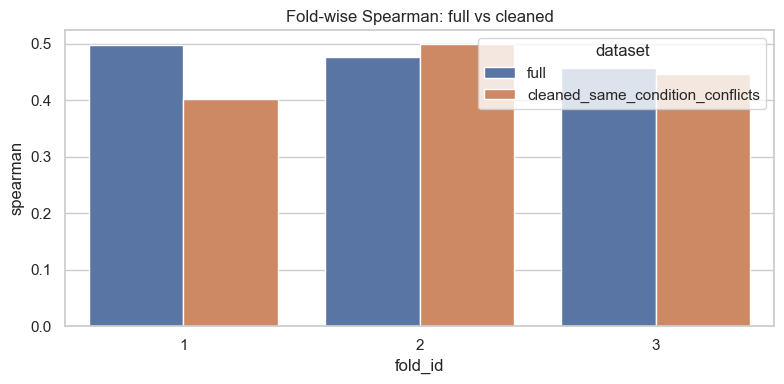

In [12]:
plt.figure(figsize=(8, 4))
sns.barplot(data=benchmark_folds, x="fold_id", y="spearman", hue="dataset")
plt.title("Fold-wise Spearman: full vs cleaned")
plt.tight_layout()

## Step 5: Check Whether Cleanup Helps Known Hotspots

Why: even if the overall metric changes only a little, cleanup may still be worthwhile if it reduces the worst hotspot failures.

In [13]:
def add_hotspot_flags(df):
    out = df.copy()
    out["flag_cn112313335a"] = out["patent_group"].eq("CN112313335A")
    out["flag_app_20"] = out["group"].eq("APP") & np.isclose(out["Concentration_nM"], 20.0, equal_nan=False)
    out["flag_inhbe_100"] = out["group"].eq("INHBE") & np.isclose(out["Concentration_nM"], 100.0, equal_nan=False)
    out["flag_mapt_hi"] = out["group"].eq("MAPT") & out["Concentration_nM"].isin([40.0, 200.0])
    return out

preds_full = add_hotspot_flags(preds_full)
preds_clean = add_hotspot_flags(preds_clean)

In [14]:
def summarize_flag(df, flag_col, dataset_label):
    sub = df.loc[df[flag_col]].copy()
    if sub.empty:
        return pd.DataFrame([{
            "dataset": dataset_label,
            "slice": flag_col,
            "n_samples": 0,
            "spearman": np.nan,
            "mae": np.nan,
            "mean_true": np.nan,
            "mean_pred": np.nan,
            "mean_bias": np.nan,
        }])
    return pd.DataFrame([{
        "dataset": dataset_label,
        "slice": flag_col,
        "n_samples": len(sub),
        "spearman": float(spearmanr(sub["y_true"], sub["y_pred"], nan_policy="omit").statistic),
        "mae": float(sub["abs_error"].mean()),
        "mean_true": float(sub["y_true"].mean()),
        "mean_pred": float(sub["y_pred"].mean()),
        "mean_bias": float(sub["prediction_bias"].mean()),
    }])

flag_cols = ["flag_cn112313335a", "flag_app_20", "flag_inhbe_100", "flag_mapt_hi"]
hotspot_tables = []
for flag_col in flag_cols:
    hotspot_tables.append(summarize_flag(preds_full, flag_col, "full"))
    hotspot_tables.append(summarize_flag(preds_clean, flag_col, "cleaned_same_condition_conflicts"))

hotspot_comparison = pd.concat(hotspot_tables, ignore_index=True)
hotspot_comparison

,dataset,slice,n_samples,spearman,mae,mean_true,mean_pred,mean_bias
0,full,flag_cn112313335a,366,-0.809342,73.222705,95.782978,22.560272,-73.222705
1,cleaned_same_condition_conflicts,flag_cn112313335a,366,-0.829266,73.419583,95.782978,22.363396,-73.419583
2,full,flag_app_20,170,-0.538620,39.857762,41.005882,61.545261,20.539379
3,cleaned_same_condition_conflicts,flag_app_20,170,-0.593234,40.445350,41.005882,62.395462,21.389581
4,full,flag_inhbe_100,180,-0.291310,38.886995,62.262167,29.998730,-32.263436
5,cleaned_same_condition_conflicts,flag_inhbe_100,180,-0.005324,39.867523,62.262167,27.187782,-35.074385
6,full,flag_mapt_hi,159,0.094450,32.744613,47.428931,68.353958,20.925031
7,cleaned_same_condition_conflicts,flag_mapt_hi,159,-0.304233,37.325273,47.428931,62.146446,14.717515


## Step 6: Optional Export

Why: if this becomes your first cleaned-data benchmark, it helps to save the summary tables for later comparison with CNN experiments.

In [15]:
if processed_dir:
    conflict_artifacts.same_condition_conflicts.to_csv(processed_dir / "same_condition_conflicts_all.csv", index=False)
    conflict_artifacts.candidate_removals.to_csv(processed_dir / "same_condition_conflicts_thresholded.csv", index=False)
    conflict_artifacts.candidate_rows.to_csv(processed_dir / "same_condition_conflict_rows_thresholded.csv", index=False)
    conflict_artifacts.summary.to_csv(processed_dir / "same_condition_conflict_export_summary.csv", index=False)
    benchmark_metrics.to_csv(processed_dir / "xgboost_cleaned_benchmark_metrics.csv", index=False)
    benchmark_folds.to_csv(processed_dir / "xgboost_cleaned_benchmark_folds.csv", index=False)
    hotspot_comparison.to_csv(processed_dir / "xgboost_cleaned_benchmark_hotspots.csv", index=False)
    cleanup_summary.to_csv(processed_dir / "xgboost_cleaned_benchmark_cleanup_summary.csv", index=False)
    print("Saved benchmark outputs to:", processed_dir)

Saved benchmark outputs to: /Users/yesminemaalej/siRNA-Pharmaceutical-Modeling-with-Foundation-Models/data/processed
